# Understanding Cargo Volumes

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from typing import Tuple

In [72]:
df = pd.read_excel("rotterdam_dataset_15.xlsx")
df = df.sort_values("Arrival_Date")

df

,Arrival_Date,Vessel_ID,Vessel_Type,Cargo_tons,Berth_Time_hr
2,2022-01-01 04:06:00,V000003,Container,9199,20.6
0,2022-01-01 06:18:00,V000001,Container,18090,19.9
3,2022-01-01 10:34:00,V000004,Container,12689,27.0
1,2022-01-01 11:07:00,V000002,Container,10940,18.7
4,2022-01-01 13:10:00,V000005,Container,9413,18.5
...,...,...,...,...,...
17070,2024-12-31 17:01:00,V017071,Container,18654,23.2
17073,2024-12-31 20:15:00,V017074,Container,14458,18.9
17078,2024-12-31 21:58:00,V017079,Bulk,57549,27.5
17071,2024-12-31 22:11:00,V017072,Container,18123,24.7


## Cargo Weights

Text(0, 0.5, 'Counts')

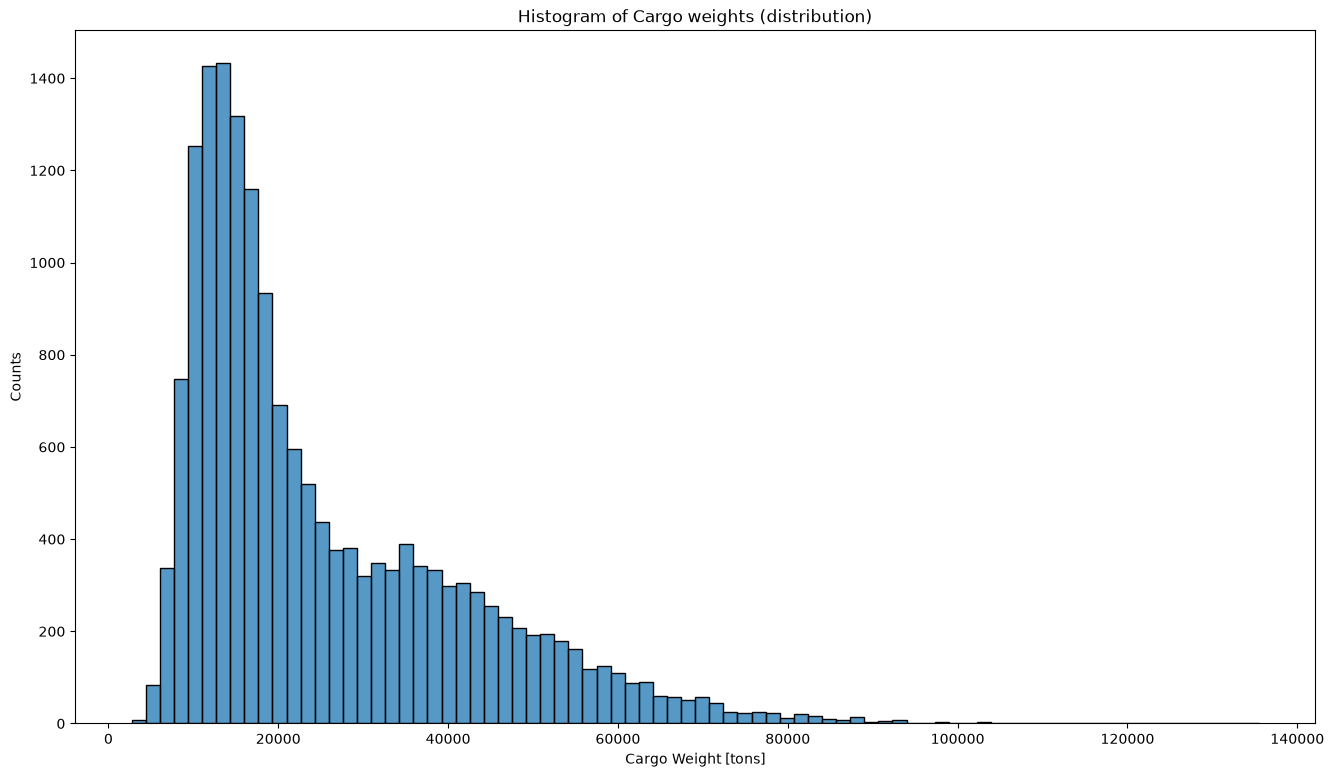

In [73]:
fig, ax = plt.subplots(figsize = (16, 9))
sns.histplot(data = df, x = "Cargo_tons", ax=ax)
ax.set_title("Histogram of Cargo weights (distribution)")
ax.set_xlabel("Cargo Weight [tons]")
ax.set_ylabel("Counts")

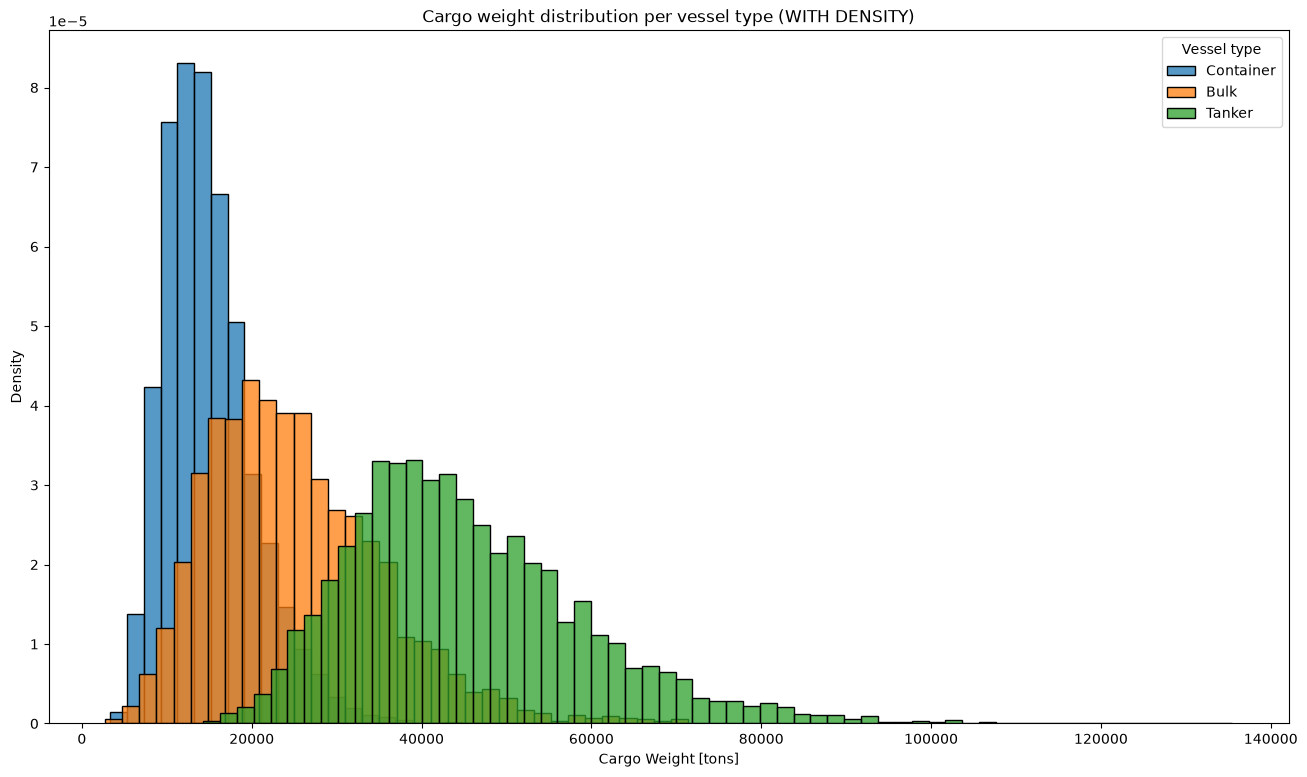

In [74]:
fig, ax = plt.subplots(figsize = (16, 9))

for t in ["Container", "Bulk", "Tanker"]:
    sns.histplot(data = df[df["Vessel_Type"] == t], x="Cargo_tons",
                 binwidth=2000, stat="density", label=t, ax=ax)

ax.set_title("Cargo weight distribution per vessel type (WITH DENSITY)")
ax.set_xlabel("Cargo Weight [tons]")
ax.set_ylabel("Density")
ax.legend(title="Vessel type")

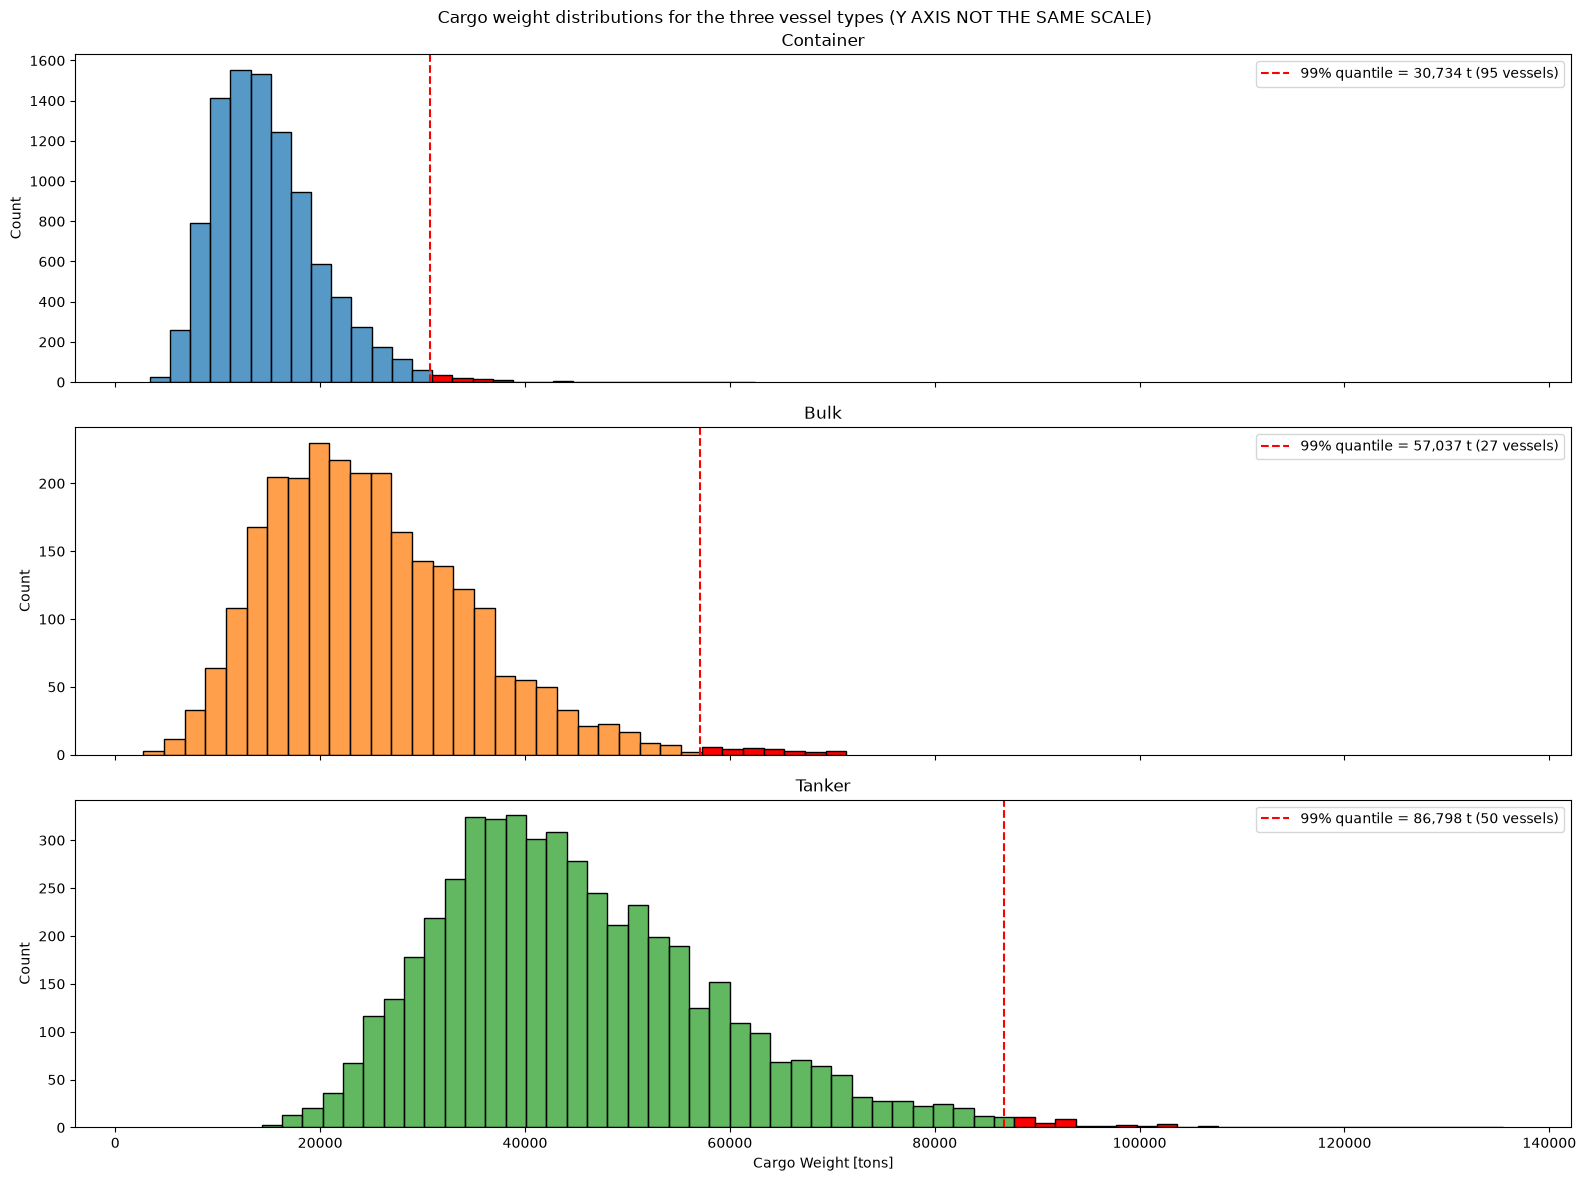

In [75]:
q = 0.99   # switch to 0.95 to widen the highlighted tail

fig, ax = plt.subplots(figsize = (16, 12), nrows=3, sharex=True)
for i, t in enumerate(["Container", "Bulk", "Tanker"]):
    weights = df[df["Vessel_Type"] == t]["Cargo_tons"]
    threshold = np.quantile(weights, q)

    sns.histplot(data = weights, binwidth=2000, color=f"C{i}", ax=ax[i])

    for bar in ax[i].patches:
        if bar.get_x() >= threshold:
            bar.set_facecolor("red")

    ax[i].axvline(threshold, color="red", linestyle="--",
                  label=f"{q:.0%} quantile = {threshold:,.0f} t ({(weights > threshold).sum()} vessels)")
    ax[i].set_title(t)
    ax[i].set_ylabel("Count")
    ax[i].legend()

ax[2].set_xlabel("Cargo Weight [tons]")
fig.suptitle("Cargo weight distributions for the three vessel types (Y AXIS NOT THE SAME SCALE)")
plt.tight_layout()

### Fitting distributions for cargo weight

In [77]:
def moments(data: pd.Series | np.ndarray) -> Tuple[float, float]:
    """
    Calculates the first two moments
    """

    M1 = np.mean(data)
    M2 = np.mean(np.pow(data,2))

    return M1, M2
    
def fit_normal(mom: Tuple[float, float]):
    M1, M2 = mom
    return stats.norm(loc=M1, scale=np.sqrt(M2 - M1**2))

def fit_gamma(mom: Tuple[float, float]):
    M1, M2 = mom
    beta = M1 / (M2 - M1**2)
    alpha = M1 * beta
    return stats.gamma(a = alpha, scale = 1/beta)

def fit_lognormal(mom: Tuple[float, float]):
    M1, M2 = mom
    var = M2 - M1 ** 2
    sigma2 = np.log(1 + var / M1 ** 2)
    mu = np.log(M1) - sigma2 / 2
    return stats.lognorm(s=np.sqrt(sigma2), scale=np.exp(mu))


In [78]:
fitters = {
    "Normal": fit_normal,
    "Gamma": fit_gamma,
    "Lognormal": fit_lognormal
    }
types = ["Container", "Bulk", "Tanker"]
combos = [(t, name) for t in types for name in fitters]


def fit_all(data: pd.DataFrame, column: str):
    """Fit every distribution to every vessel type by the method of moments."""
    fitted = {}
    rows = []

    for t, name in combos:
        x = data.loc[data["Vessel_Type"] == t, column].to_numpy(float)
        dist = fitters[name](moments(x))
        fitted[(t, name)] = dist
        rows.append({
            "Vessel_Type": t,
            "Distribution": name,
            "Parameters": ", ".join(f"{k}={v:,.4g}" for k, v in dist.kwds.items()),
            "Skew_fit":    dist.stats(moments="s").item(),
            "Skew_data":   stats.skew(x),
            "Median_fit":  dist.median(),
            "Median_data": np.median(x),
            "Q99_fit":     dist.ppf(0.99),
            "Q99_data":    np.quantile(x, 0.99),
            "P(X<0)":      dist.cdf(0),
            "KS_p":        stats.kstest(x, dist.cdf).pvalue,
        })

    return fitted, pd.DataFrame(rows)


def plot_fits(fitted: dict, column: str, label: str, binwidth=None, cap_q=0.999):
    """Histogram of each vessel type with each fitted PDF drawn on top."""
    fig, ax = plt.subplots(figsize = (18, 12), nrows=3, ncols=3, sharex="row", sharey="row")

    for i, t in enumerate(types):
        values = df[df["Vessel_Type"] == t][column]
        cap = np.quantile(values, cap_q)
        xs = np.linspace(values.min(), cap, 500)
        margin = 0.05 * (cap - values.min())

        for j, name in enumerate(fitters):
            ys = fitted[(t, name)].pdf(xs)

            sns.histplot(data=values, stat="density", alpha=0.5, binwidth=binwidth, ax=ax[i, j], color=f"C{j}")
            sns.lineplot(x=xs, y=ys, color="C3", ax=ax[i, j])
            ax[i, j].set_xlim(values.min() - margin, cap)

            ax[i, j].set_title(f"{t} - {name}")
            ax[i, j].set_ylabel("Density" if j == 0 else "")
            ax[i, j].set_xlabel(label if i == 2 else "")

    fig.suptitle(f"{label}: histograms with fitted PDFs (method of moments)")
    plt.tight_layout()

In [79]:
cargo_fitted, cargo_results = fit_all(df, "Cargo_tons")
cargo_results.round(4)

,Vessel_Type,Distribution,Parameters,Skew_fit,Skew_data,Median_fit,Median_data,Q99_fit,Q99_data,P(X<0),KS_p
0,Container,Normal,"loc=1.489e+04, scale=5,268",0.0000,1.0874,14894.2692,14099.5,27148.3696,30733.60,0.0023,0.0000
1,Container,Gamma,"a=7.995, scale=1,863",0.7073,1.0874,14278.1102,14099.5,29793.7893,30733.60,0.0000,0.0005
2,Container,Lognormal,"s=0.3433, scale=1.404e+04",1.1052,1.0874,14041.9752,14099.5,31207.9461,30733.60,0.0000,0.8534
3,Bulk,Normal,"loc=2.508e+04, scale=1.025e+04",0.0000,0.8946,25075.2896,23582.0,48910.0694,57037.05,0.0072,0.0000
4,Bulk,Gamma,"a=5.99, scale=4,186",0.8172,0.8946,23694.5221,23582.0,54812.9345,57037.05,0.0000,0.9408
5,Bulk,Lognormal,"s=0.3929, scale=2.321e+04",1.2940,0.8946,23212.4092,23582.0,57903.1760,57037.05,0.0000,0.0399
6,Tanker,Normal,"loc=4.524e+04, scale=1.395e+04",0.0000,0.9083,45238.4566,43051.0,77689.0633,86798.04,0.0006,0.0000
7,Tanker,Gamma,"a=10.52, scale=4,301",0.6167,0.9083,43813.0873,43051.0,83830.7384,86798.04,0.0000,0.0038
8,Tanker,Lognormal,"s=0.3014, scale=4.323e+04",0.9544,0.9083,43229.9986,43051.0,87150.2213,86798.04,0.0000,0.7931


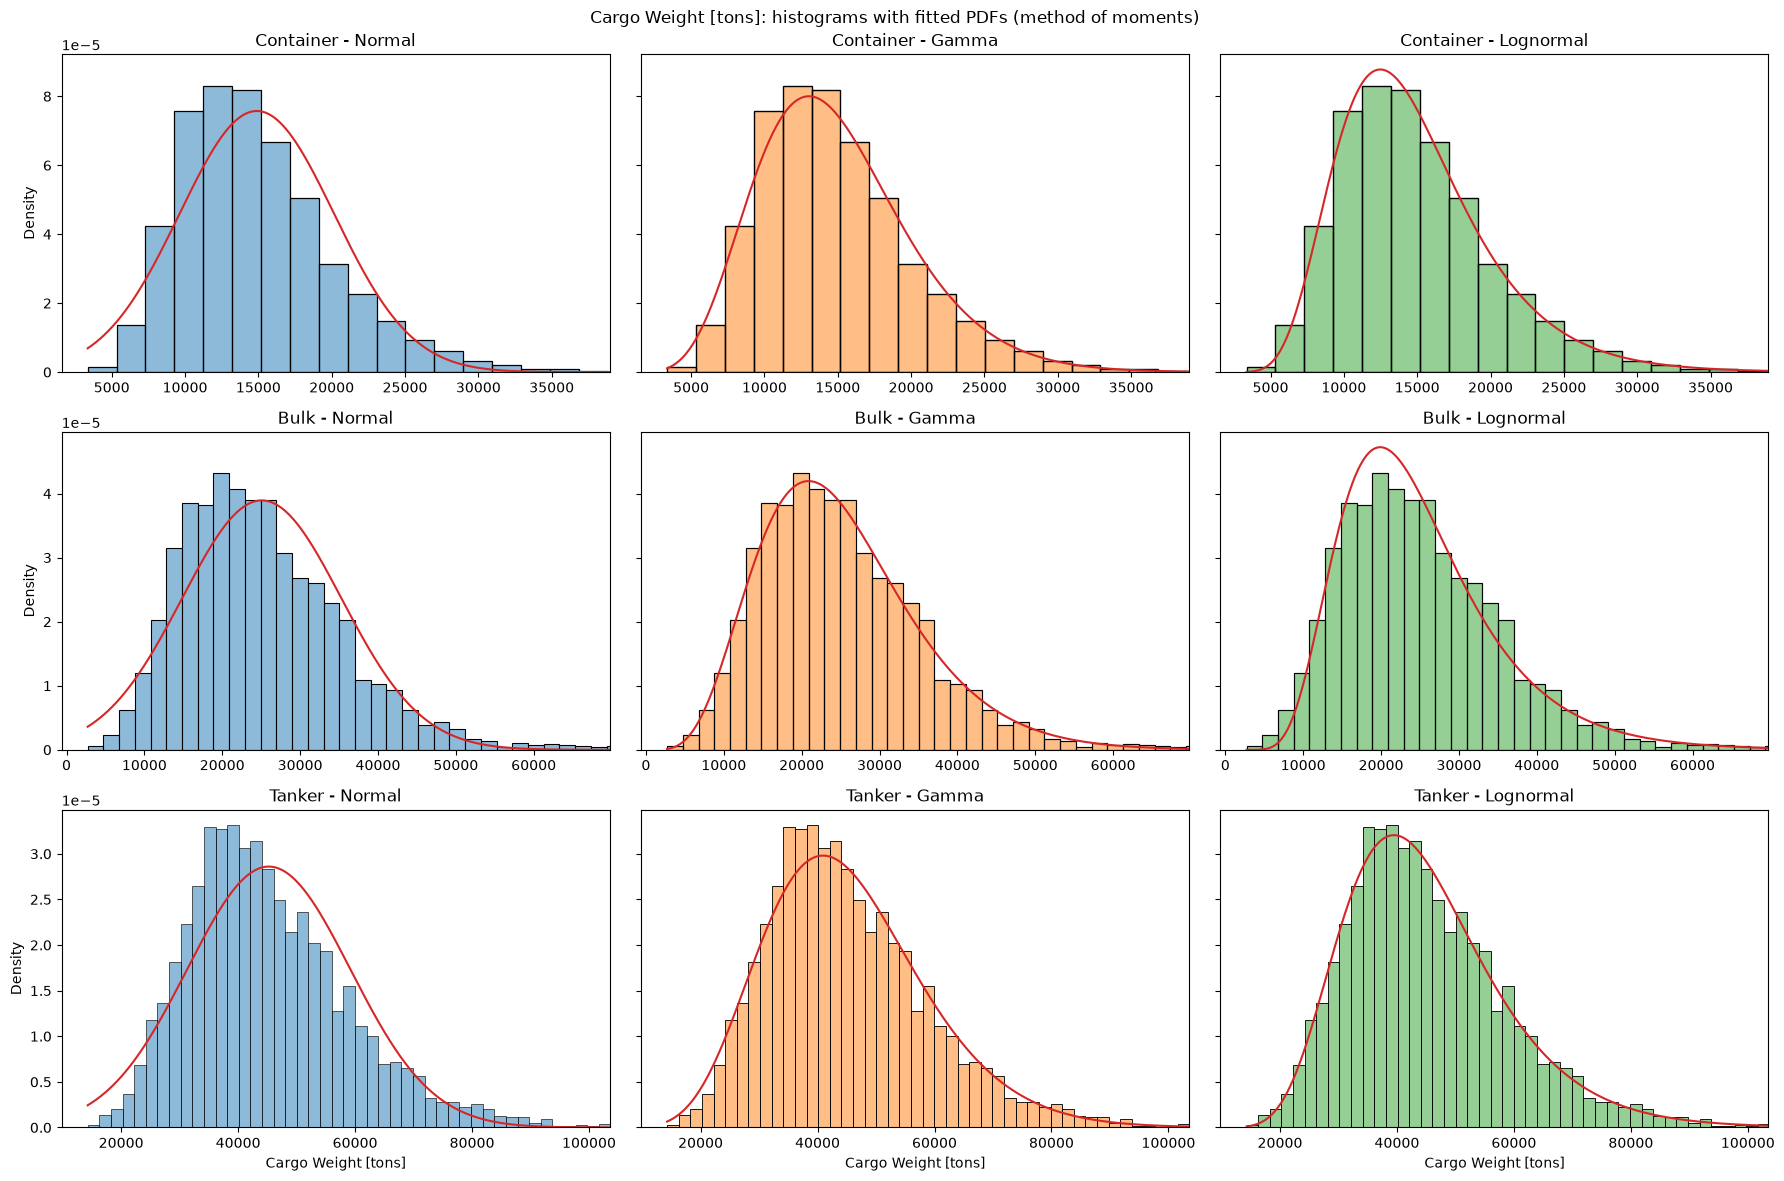

In [80]:
plot_fits(cargo_fitted, "Cargo_tons", "Cargo Weight [tons]", binwidth=2000)

## Berth Times

Text(0, 0.5, 'Counts')

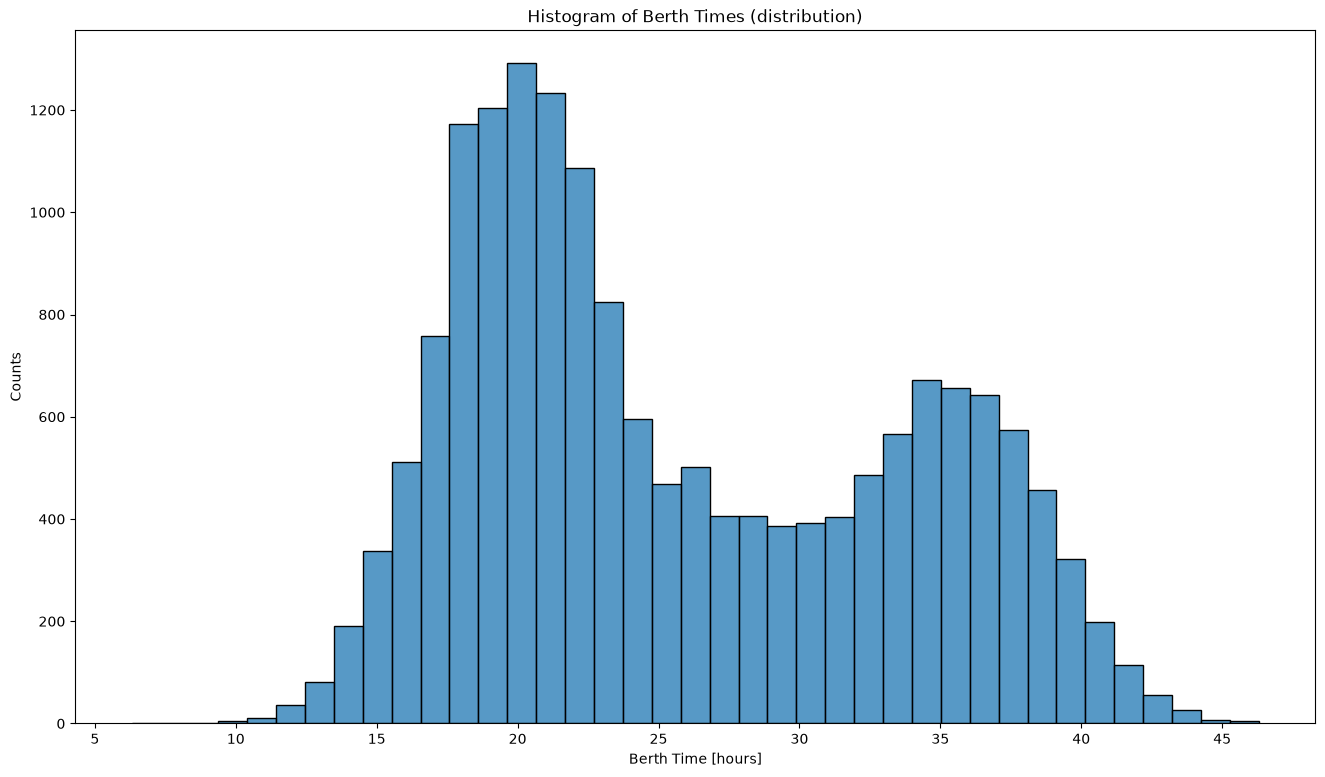

In [81]:
fig, ax = plt.subplots(figsize = (16, 9))
sns.histplot(data = df, x = "Berth_Time_hr", ax=ax)
ax.set_title("Histogram of Berth Times (distribution)")
ax.set_xlabel("Berth Time [hours]")
ax.set_ylabel("Counts")

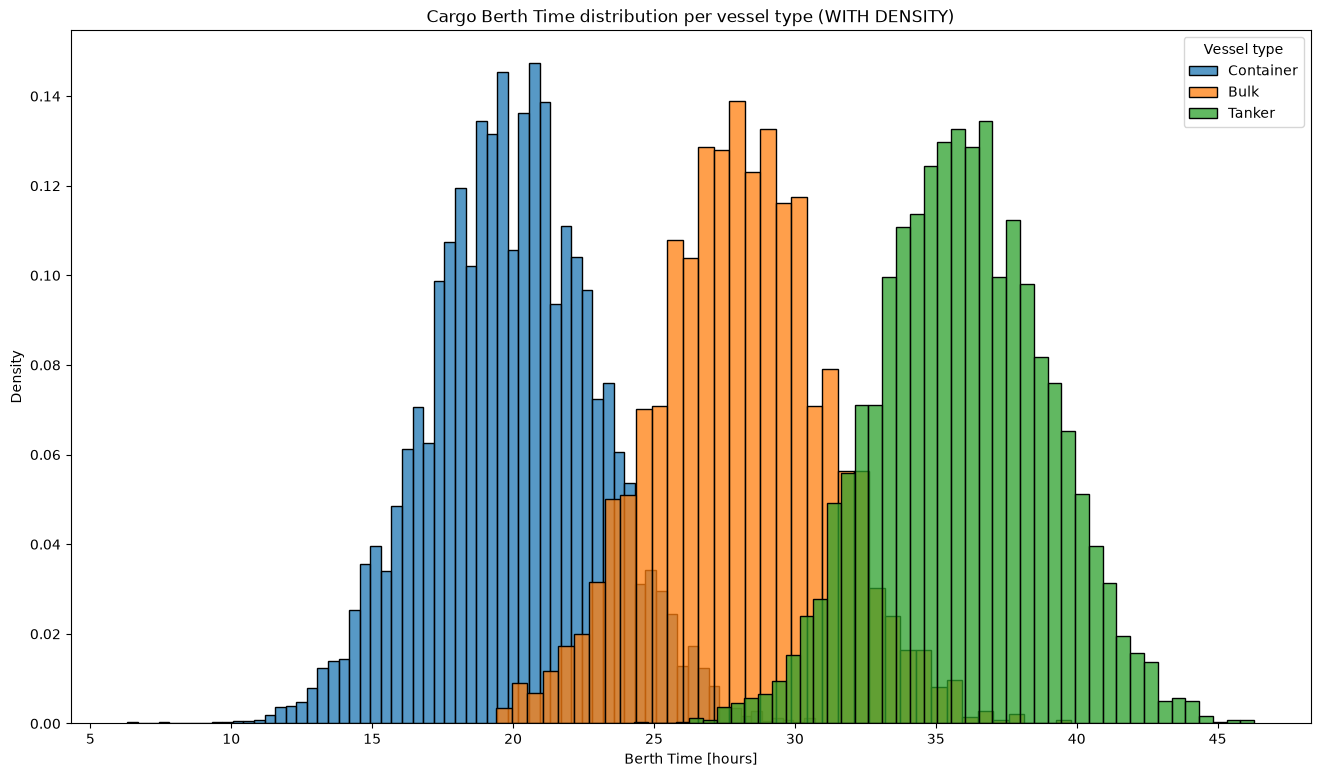

In [82]:
fig, ax = plt.subplots(figsize = (16, 9))

for t in ["Container", "Bulk", "Tanker"]:
    sns.histplot(data = df[df["Vessel_Type"] == t], x="Berth_Time_hr",
                 stat="density", label=t, ax=ax)

ax.set_title("Cargo Berth Time distribution per vessel type (WITH DENSITY)")
ax.set_xlabel("Berth Time [hours]")
ax.set_ylabel("Density")
ax.legend(title="Vessel type")

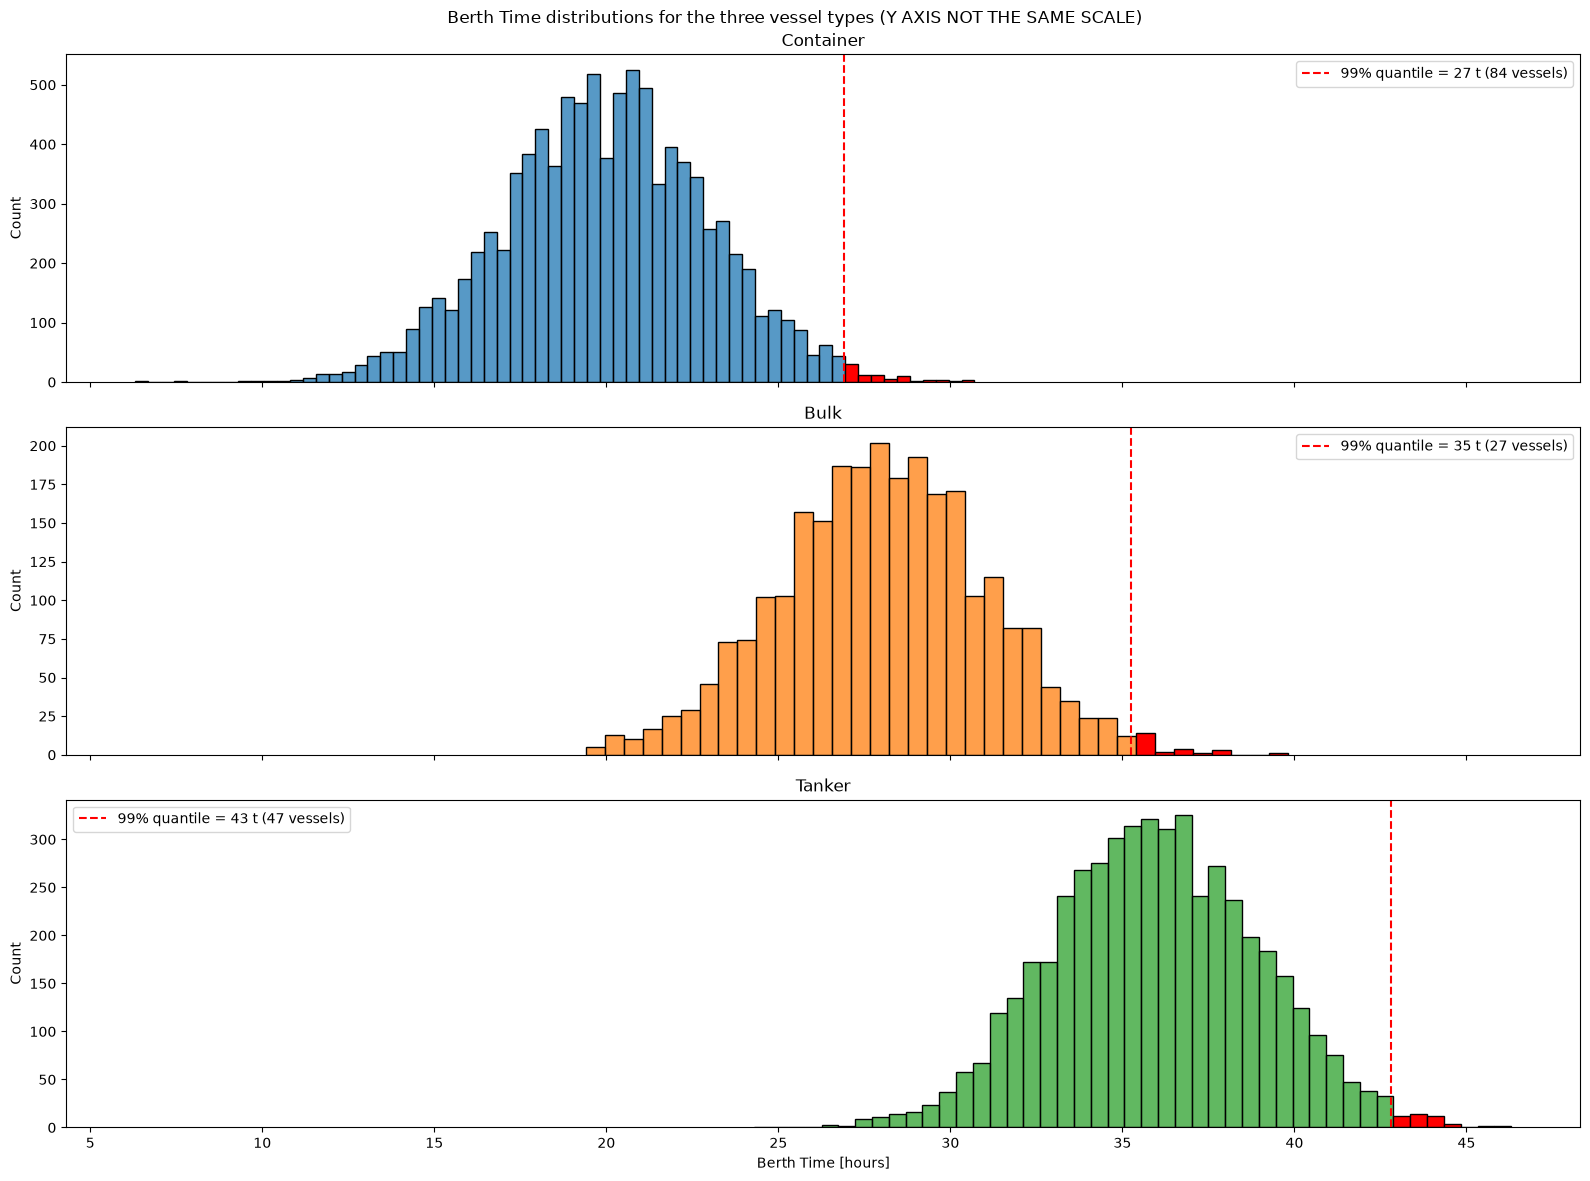

In [83]:
q = 0.99   # switch to 0.95 to widen the highlighted tail

fig, ax = plt.subplots(figsize = (16, 12), nrows=3, sharex=True)
for i, t in enumerate(["Container", "Bulk", "Tanker"]):
    weights = df[df["Vessel_Type"] == t]["Berth_Time_hr"]
    threshold = np.quantile(weights, q)

    sns.histplot(data = weights, color=f"C{i}", ax=ax[i])

    for bar in ax[i].patches:
        if bar.get_x() >= threshold:
            bar.set_facecolor("red")

    ax[i].axvline(threshold, color="red", linestyle="--",
                  label=f"{q:.0%} quantile = {threshold:,.0f} t ({(weights > threshold).sum()} vessels)")
    ax[i].set_title(t)
    ax[i].set_ylabel("Count")
    ax[i].legend()

ax[2].set_xlabel("Berth Time [hours]")
fig.suptitle("Berth Time distributions for the three vessel types (Y AXIS NOT THE SAME SCALE)")
plt.tight_layout()

### Fitted distributions for berth times

In [84]:
berth_fitted, berth_results = fit_all(df, "Berth_Time_hr")
berth_results.round(4)

,Vessel_Type,Distribution,Parameters,Skew_fit,Skew_data,Median_fit,Median_data,Q99_fit,Q99_data,P(X<0),KS_p
0,Container,Normal,"loc=19.99, scale=2.969",0.0000,-0.0103,19.9860,20.0,26.8941,26.900,0.0,0.1908
1,Container,Gamma,"a=45.3, scale=0.4412",0.2972,-0.0103,19.8392,20.0,27.5349,26.900,0.0,0.0000
2,Container,Lognormal,"s=0.1478, scale=19.77",0.4490,-0.0103,19.7690,20.0,27.8790,26.900,0.0,0.0000
3,Bulk,Normal,"loc=28.08, scale=3.012",0.0000,0.0431,28.0768,28.1,35.0833,35.263,0.0,0.6389
4,Bulk,Gamma,"a=86.9, scale=0.3231",0.2145,0.0431,27.9692,28.1,35.5544,35.263,0.0,0.1205
5,Bulk,Lognormal,"s=0.107, scale=27.92",0.3230,0.0431,27.9167,28.1,35.8040,35.263,0.0,0.0237
6,Tanker,Normal,"loc=35.93, scale=2.991",0.0000,0.0300,35.9340,35.9,42.8929,42.800,0.0,0.2126
7,Tanker,Gamma,"a=144.3, scale=0.249",0.1665,0.0300,35.8511,35.9,43.2568,42.800,0.0,0.0481
8,Tanker,Lognormal,"s=0.0831, scale=35.81",0.2503,0.0300,35.8102,35.9,43.4476,42.800,0.0,0.0055


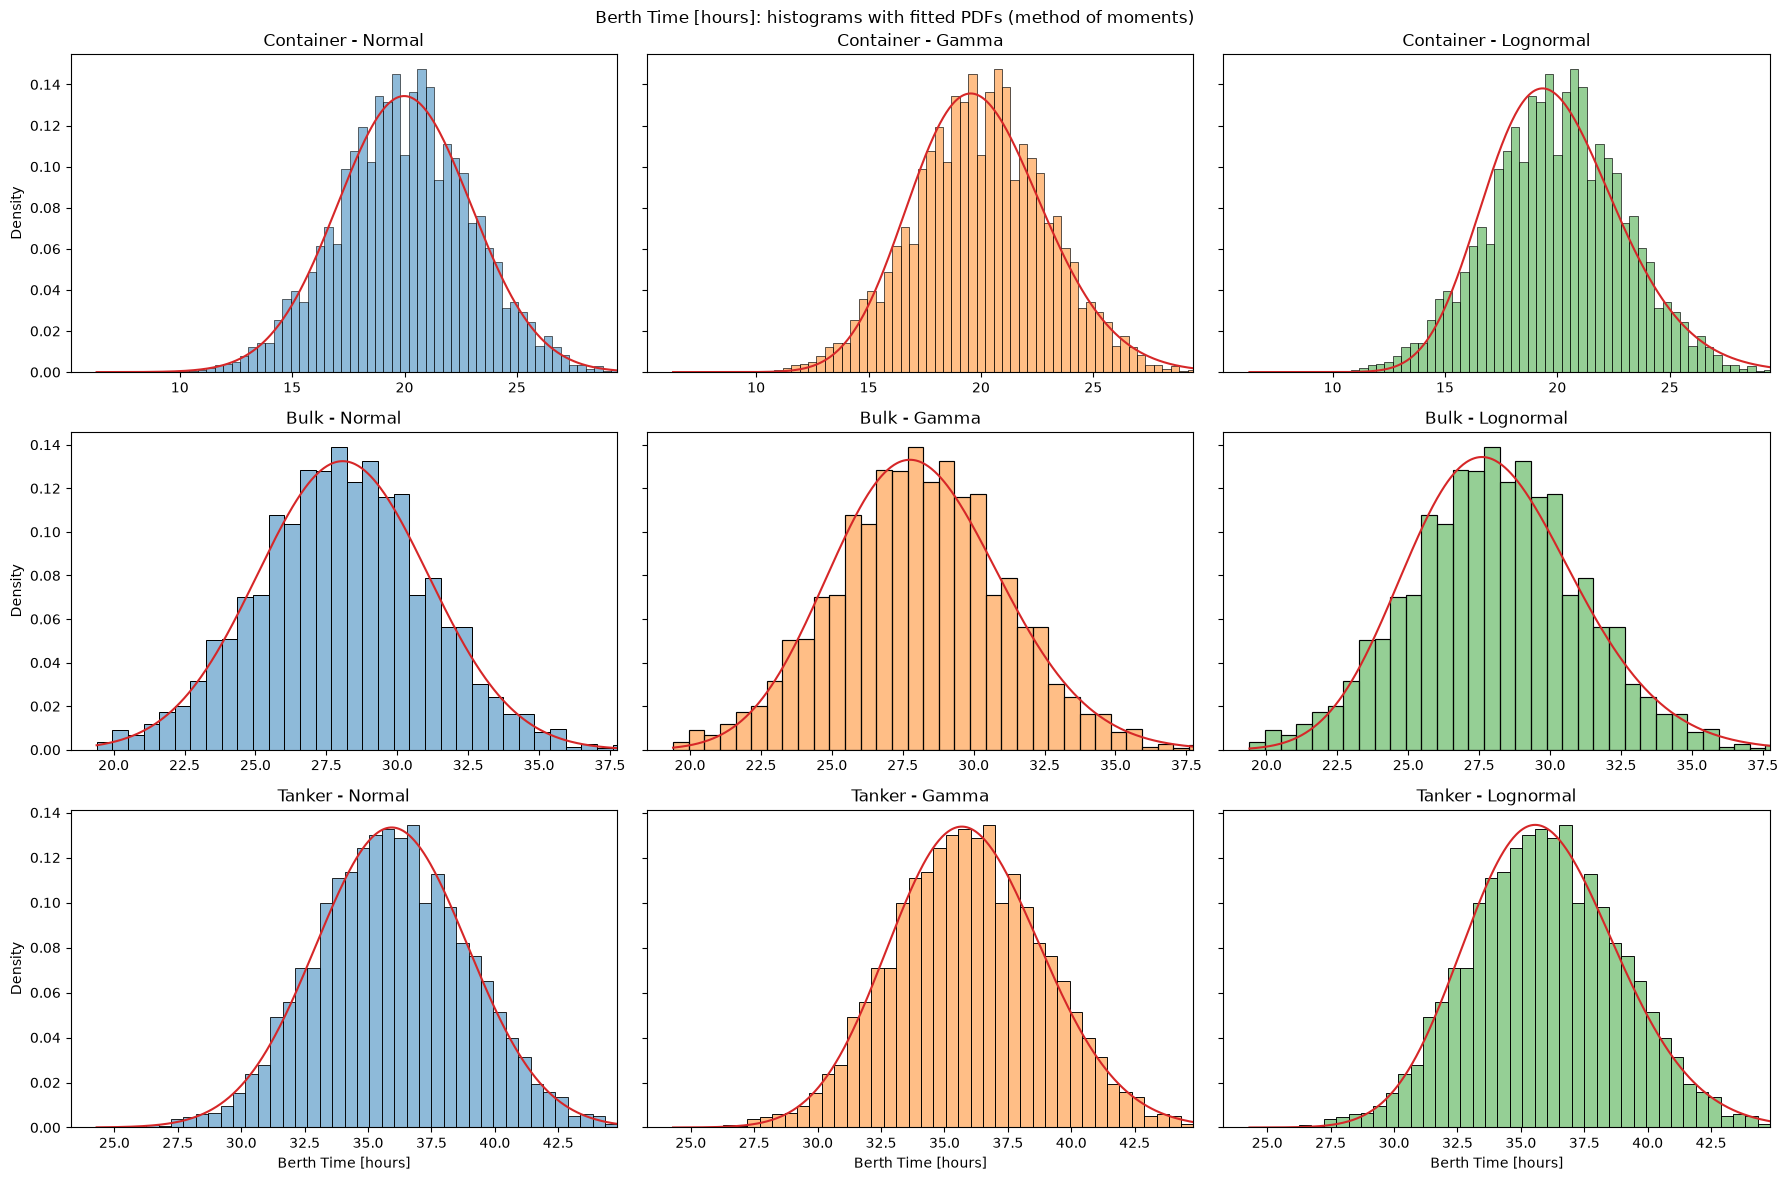

In [85]:
plot_fits(berth_fitted, "Berth_Time_hr", "Berth Time [hours]")

In [86]:
corr_rows = [{
    "Vessel_Type": "All types",
    "n": len(df),
    "Correlation": df["Cargo_tons"].corr(df["Berth_Time_hr"]),
}]

for t in types:
    g = df[df["Vessel_Type"] == t]
    corr_rows.append({
        "Vessel_Type": t,
        "n": len(g),
        "Correlation": g["Cargo_tons"].corr(g["Berth_Time_hr"]),
    })

correlations = pd.DataFrame(corr_rows).set_index("Vessel_Type")
correlations.round(4)

,n,Correlation
Vessel_Type,,
All types,17081,0.7405
Container,9496,-0.0047
Bulk,2638,0.0032
Tanker,4947,-0.0297


### Seasonality check

Arrival rates vary across the year, but vessel size and berth time do not,
so seasonality enters the model only through the arrival rate.


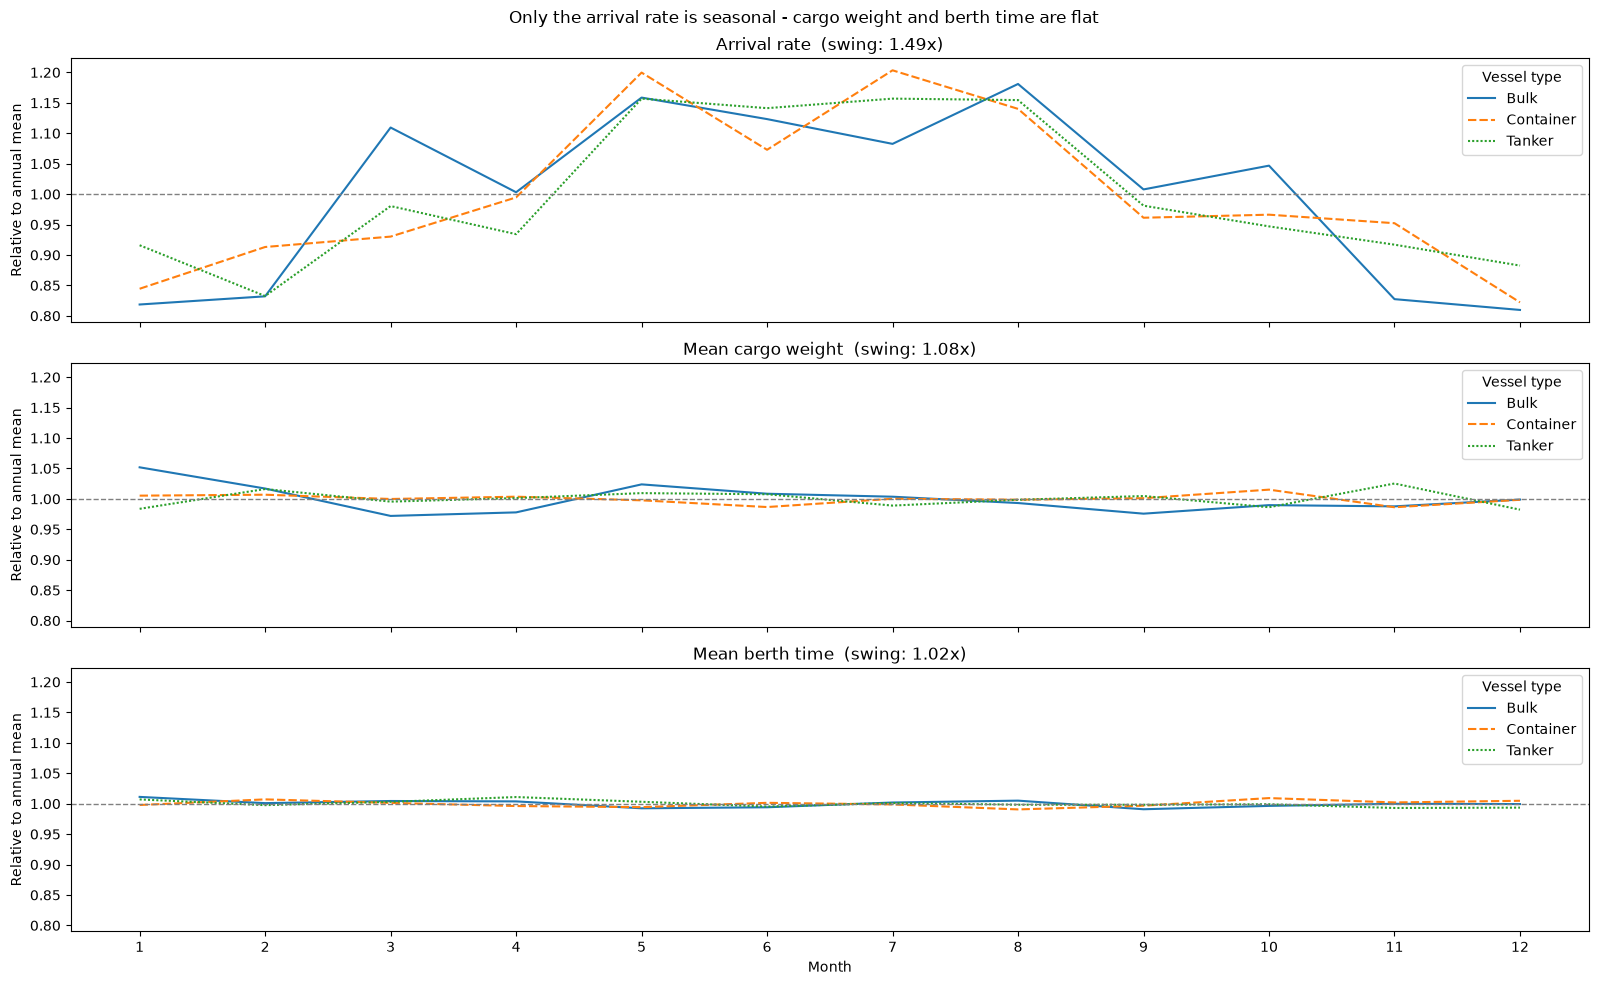

In [87]:
month = df["Arrival_Date"].dt.month
days_per_month = df["Arrival_Date"].dt.normalize().drop_duplicates().dt.month.value_counts().sort_index()

# Everything as a ratio to that type's own overall level, so the three are comparable
arrival_rate = df.groupby([month, "Vessel_Type"], observed=True).size().unstack().div(days_per_month, axis=0)
cargo_mean = df.groupby([month, "Vessel_Type"], observed=True)["Cargo_tons"].mean().unstack()
berth_mean = df.groupby([month, "Vessel_Type"], observed=True)["Berth_Time_hr"].mean().unstack()

panels = {
    "Arrival rate": arrival_rate,
    "Mean cargo weight": cargo_mean,
    "Mean berth time": berth_mean,
}

fig, ax = plt.subplots(figsize = (16, 10), nrows=3, sharex=True, sharey=True)

for i, (name, table) in enumerate(panels.items()):
    relative = table / table.mean()
    sns.lineplot(data=relative, ax=ax[i])
    ax[i].axhline(1.0, color="grey", linestyle="--", linewidth=1)
    ax[i].set_title(f"{name}  (swing: {relative.max().max() / relative.min().min():.2f}x)")
    ax[i].set_ylabel("Relative to annual mean")
    ax[i].legend(title="Vessel type")

ax[2].set_xlabel("Month")
ax[2].set_xticks(range(1, 13))
fig.suptitle("Only the arrival rate is seasonal - cargo weight and berth time are flat")
plt.tight_layout()